**Task** : Import and install Tidyverse package

In [ ]:

install.packages("tidyverse")
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


**Task:** Load the CSV data and Check Whether you have missing values and whether you have a mix of data typesin the column that describes the area square feet

The data can be found [here](https://www.kaggle.com/code/mannatpruthi/house-prediction/input)

In [ ]:
data <- read.csv("sample_data/bengaluru_house_prices.csv")

Viewing the data inside the csv

In [ ]:
View(data)

area_type,availability,location,size,society,total_sqft,bath,balcony,price
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2,1,39.07
Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5,3,120.00
Built-up Area,Ready To Move,Uttarahalli,3 BHK,,1440,2,3,62.00
Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3,1,95.00
Super built-up Area,Ready To Move,Kothanur,2 BHK,,1200,2,1,51.00
Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2,1,38.00
Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4,NA,204.00
Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4,NA,600.00
Super built-up Area,Ready To Move,Marathahalli,3 BHK,,1310,3,1,63.25


\**Task:** Create a function that returns the data after filtering out any missing values and mismatch in datatyes
Arguments: Dataframe Column
Returns: Only Numeric dtypes of the selected column

In [ ]:
# Creation of the clean data function
clean_data <- function(data, column) {
  x <- data[[column]]

  x <- suppressWarnings(as.numeric(x)) # Strictly specifying numeric dtypes
  x <- x[!is.na(x)] # Filtering out missing values

  return(x)
}

Checking the nature of the data type of total_sqft (character, logical, numeric)

In [ ]:
class(data$total_sqft)

[1] "numeric"

Converting total_sqft to numeric before plotting

In [ ]:
data$total_sqft <- suppressWarnings(as.numeric(data$total_sqft))

**Task :** Using the Loaded data create a scatter plot and explain whether the price of a house affects the price of a house
Create a second plot that plots the area in the y axis

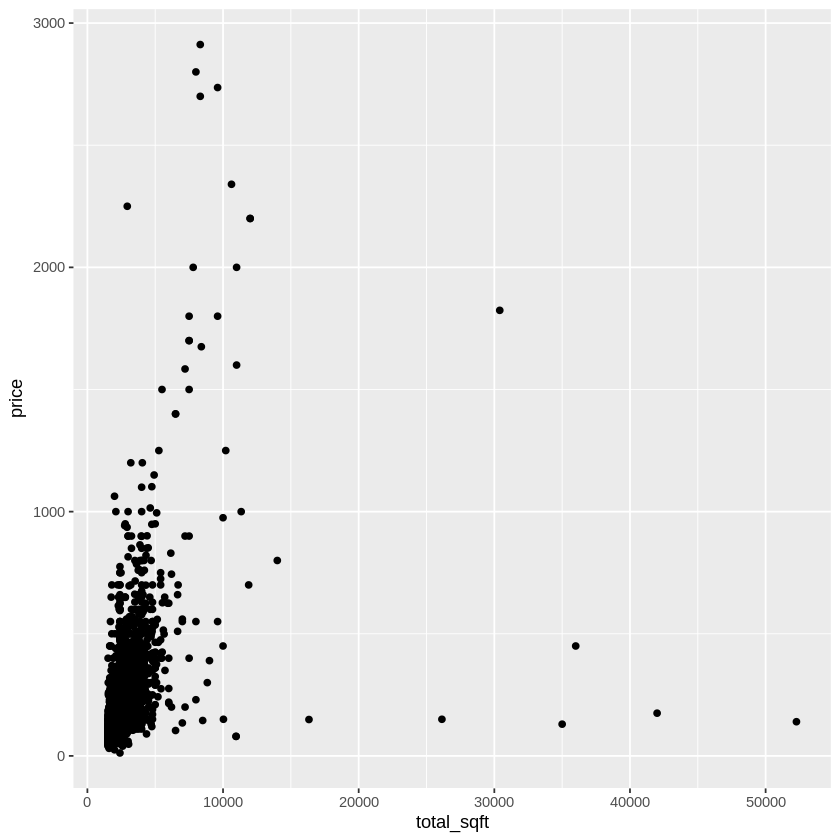

In [ ]:
na.omit(data) %>%
  filter(total_sqft > mean(total_sqft) ) %>%
  ggplot(aes(x = total_sqft, y = price )) +
  geom_point()


According to the scatter plot, most houses with a lower total square feet number tend to have a lower corresponding price, and viceversa. Nonetheless, they are some outliners, where a larger total square feet number corresponds to a lower price, and vice versa.

Second scatter plot showing area on the y axis

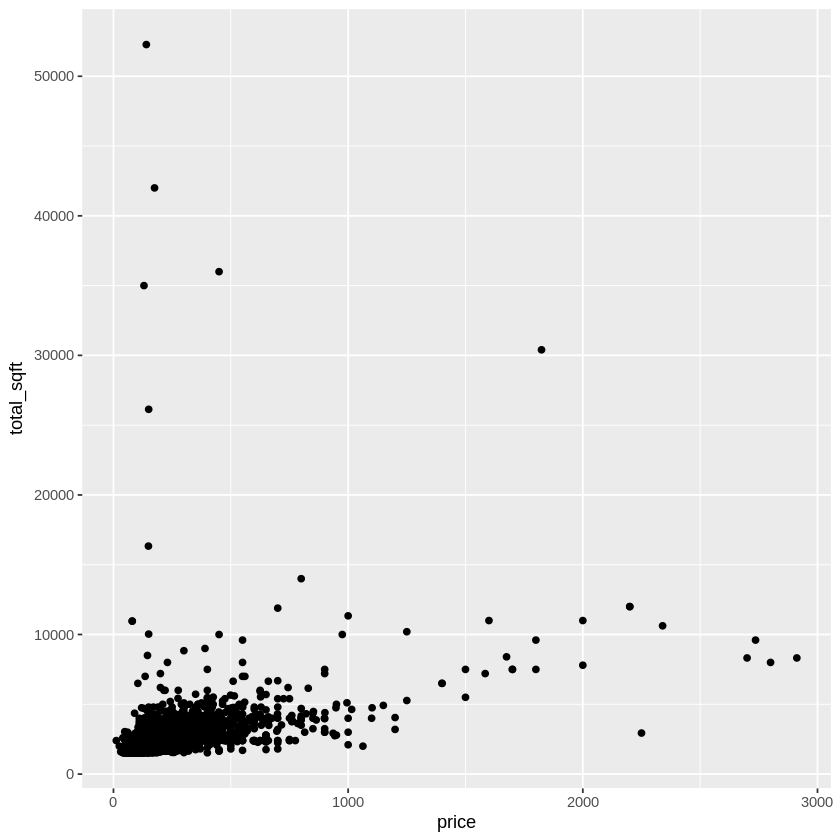

In [ ]:
na.omit(data) %>%
  filter(total_sqft > mean(total_sqft)) %>%
  ggplot(aes(x = price, y = total_sqft)) +
  geom_point()

**Task:** Ensure the values in the y - axis are values of the area that are greater than the man area in the column total_sqft

Verifying the mean of total_sqft

In [ ]:
mean(as.numeric(data$total_sqft), na.rm = TRUE)

[1] 1554.942

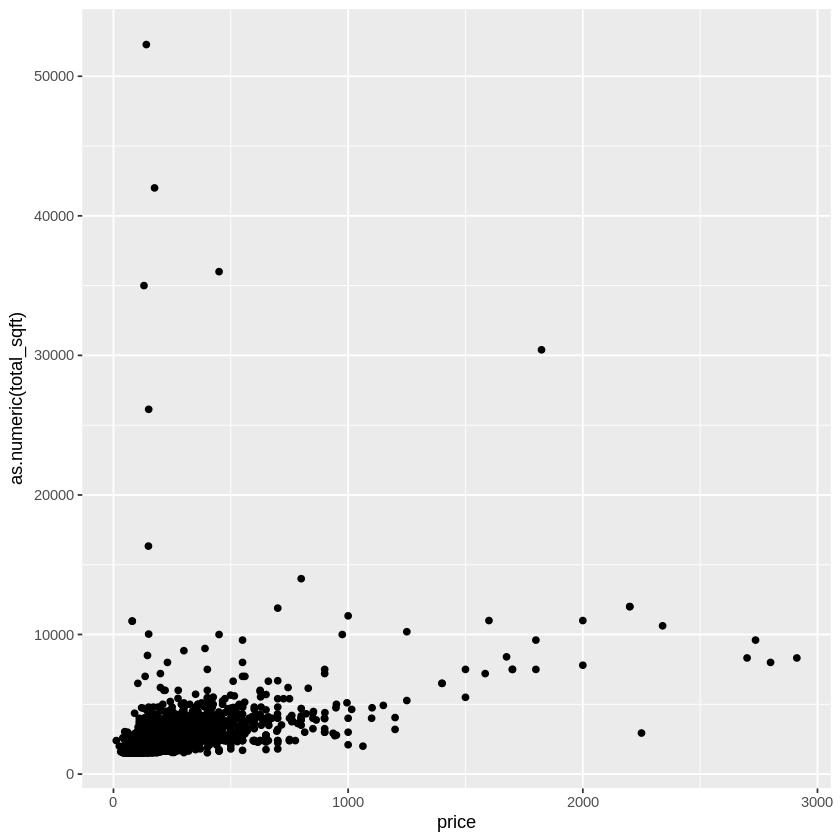

In [ ]:
na.omit(data) %>%
  filter(total_sqft > mean(as.numeric(total_sqft) , na.rm = TRUE)) %>%
  ggplot(aes(x = price, y = as.numeric(total_sqft))) +
  geom_point()